# 08 Final Visuals

## Purpose

This notebook creates final report-ready visuals for the Customer Personality Analysis project. The visuals summarize customer behavior patterns, cluster profiles, supervised model performance, and the answer to the research question about whether cluster-based segmentation improved prediction.

This notebook does not rerun clustering, retrain supervised models, modify processed datasets, change cluster labels, or change the supervised target.

## Step Dependencies

**Required input files**

- `data/processed/customer_features.csv`
- `data/processed/customer_clustered.csv`
- `data/processed/modeling_data.csv`
- `reports/cluster_profile_summary.csv`
- `reports/model_evaluation_summary.csv`
- `reports/feature_set_comparison_summary.csv`

**Required columns**

- Customer/profile columns: `cluster`, `response`, `income`, `age`, `children_total`, `household_size`, `recency`, `total_spending`, `total_purchases`, `average_spend_per_purchase`, `total_campaign_acceptances`, `any_campaign_acceptance`, `education`, `marital_status`, `has_children`
- Report metric columns: `feature_set`, `model_name`, `best_model_for_feature_set`, `accuracy`, `precision_positive`, `recall_positive`, `f1_positive`, `roc_auc`, `pr_auc`, `cluster_size`, `cluster_pct`, `proposed_segment_name`

**Required Python packages**

- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `pathlib`

**Prior project decisions this step depends on**

- k = 4 was retained because clusters were interpretable after profiling.
- Cluster labels are useful for customer interpretation.
- Cluster labels did not improve supervised prediction in Feature Set B.
- Historical campaign behavior substantially improved predictive performance in Feature Set C.
- Response is imbalanced, so PR-AUC, recall, F1, and threshold tradeoffs matter more than accuracy alone.

**Output files later steps will depend on**

- `reports/figures/final_*.png`
- `reports/final_visuals_summary.csv`
- `notebooks/08_final_visuals.ipynb`

## Setup and Validation

Load all required inputs, validate required files and columns, and define small helper functions for consistent figure saving.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORTS_DIR / "figures"
SUMMARY_PATH = REPORTS_DIR / "final_visuals_summary.csv"

INPUT_PATHS = {
    "customer_features": DATA_DIR / "customer_features.csv",
    "customer_clustered": DATA_DIR / "customer_clustered.csv",
    "modeling_data": DATA_DIR / "modeling_data.csv",
    "cluster_profile_summary": REPORTS_DIR / "cluster_profile_summary.csv",
    "model_evaluation_summary": REPORTS_DIR / "model_evaluation_summary.csv",
    "feature_set_comparison_summary": REPORTS_DIR / "feature_set_comparison_summary.csv",
}

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 180
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

missing_files = [name for name, path in INPUT_PATHS.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required input files: {missing_files}")

customer_features = pd.read_csv(INPUT_PATHS["customer_features"])
customer_clustered = pd.read_csv(INPUT_PATHS["customer_clustered"])
modeling_data = pd.read_csv(INPUT_PATHS["modeling_data"])
cluster_profile_summary = pd.read_csv(INPUT_PATHS["cluster_profile_summary"])
model_evaluation_summary = pd.read_csv(INPUT_PATHS["model_evaluation_summary"])
feature_set_comparison = pd.read_csv(INPUT_PATHS["feature_set_comparison_summary"])

print("Required input files found:")
for name, path in INPUT_PATHS.items():
    print(f"- {name}: {path}")

print("\nLoaded shapes:")
print(f"customer_features: {customer_features.shape}")
print(f"customer_clustered: {customer_clustered.shape}")
print(f"modeling_data: {modeling_data.shape}")
print(f"cluster_profile_summary: {cluster_profile_summary.shape}")
print(f"model_evaluation_summary: {model_evaluation_summary.shape}")
print(f"feature_set_comparison: {feature_set_comparison.shape}")

Required input files found:
- customer_features: /Users/arjun/Documents/Intro DS final/data/processed/customer_features.csv
- customer_clustered: /Users/arjun/Documents/Intro DS final/data/processed/customer_clustered.csv
- modeling_data: /Users/arjun/Documents/Intro DS final/data/processed/modeling_data.csv
- cluster_profile_summary: /Users/arjun/Documents/Intro DS final/reports/cluster_profile_summary.csv
- model_evaluation_summary: /Users/arjun/Documents/Intro DS final/reports/model_evaluation_summary.csv
- feature_set_comparison_summary: /Users/arjun/Documents/Intro DS final/reports/feature_set_comparison_summary.csv

Loaded shapes:
customer_features: (2213, 53)
customer_clustered: (2213, 54)
modeling_data: (2213, 32)
cluster_profile_summary: (4, 14)
model_evaluation_summary: (18, 13)
feature_set_comparison: (3, 9)


In [2]:
required_clustered_columns = {
    "cluster",
    "response",
    "income",
    "age",
    "children_total",
    "household_size",
    "recency",
    "total_spending",
    "total_purchases",
    "average_spend_per_purchase",
    "total_campaign_acceptances",
    "any_campaign_acceptance",
    "education",
    "marital_status",
    "has_children",
}
required_cluster_summary_columns = {
    "cluster",
    "cluster_size",
    "cluster_pct",
    "proposed_segment_name",
    "median_income",
    "avg_total_spending",
    "avg_total_purchases",
    "avg_children_total",
    "response_rate",
}
required_evaluation_columns = {
    "feature_set",
    "model_name",
    "accuracy",
    "precision_positive",
    "recall_positive",
    "f1_positive",
    "roc_auc",
    "pr_auc",
}
required_feature_set_columns = {
    "feature_set",
    "best_model_for_feature_set",
    "accuracy",
    "precision_positive",
    "recall_positive",
    "f1_positive",
    "roc_auc",
    "pr_auc",
}

validation_checks = {
    "customer_clustered": sorted(required_clustered_columns - set(customer_clustered.columns)),
    "cluster_profile_summary": sorted(required_cluster_summary_columns - set(cluster_profile_summary.columns)),
    "model_evaluation_summary": sorted(required_evaluation_columns - set(model_evaluation_summary.columns)),
    "feature_set_comparison_summary": sorted(required_feature_set_columns - set(feature_set_comparison.columns)),
}

failed_checks = {name: missing for name, missing in validation_checks.items() if missing}
if failed_checks:
    raise KeyError(f"Missing required columns: {failed_checks}")

print("Required columns validated.")
display(pd.DataFrame({
    "dataset": list(validation_checks.keys()),
    "missing_required_columns": [validation_checks[name] for name in validation_checks],
}))

Required columns validated.


,dataset,missing_required_columns
0,customer_clustered,[]
1,cluster_profile_summary,[]
2,model_evaluation_summary,[]
3,feature_set_comparison_summary,[]


In [3]:
figure_records = []

def save_figure(filename, title, project_section, purpose, key_message):
    path = FIGURE_DIR / filename
    plt.savefig(path, bbox_inches="tight")
    figure_records.append({
        "figure_filename": filename,
        "figure_title": title,
        "project_section": project_section,
        "purpose": purpose,
        "key_message": key_message,
    })
    return path

cluster_name_map = dict(zip(cluster_profile_summary["cluster"], cluster_profile_summary["proposed_segment_name"]))
cluster_profile_summary["cluster_label"] = cluster_profile_summary.apply(
    lambda row: f"Cluster {int(row['cluster'])}: {row['proposed_segment_name']}",
    axis=1,
)
customer_clustered["cluster_label"] = customer_clustered["cluster"].map(
    lambda cluster_id: f"Cluster {int(cluster_id)}"
)

## Final Visual A: Cluster Profile Heatmap

This heatmap standardizes cluster averages relative to the overall dataset, showing which clusters are above or below average on key profile variables.

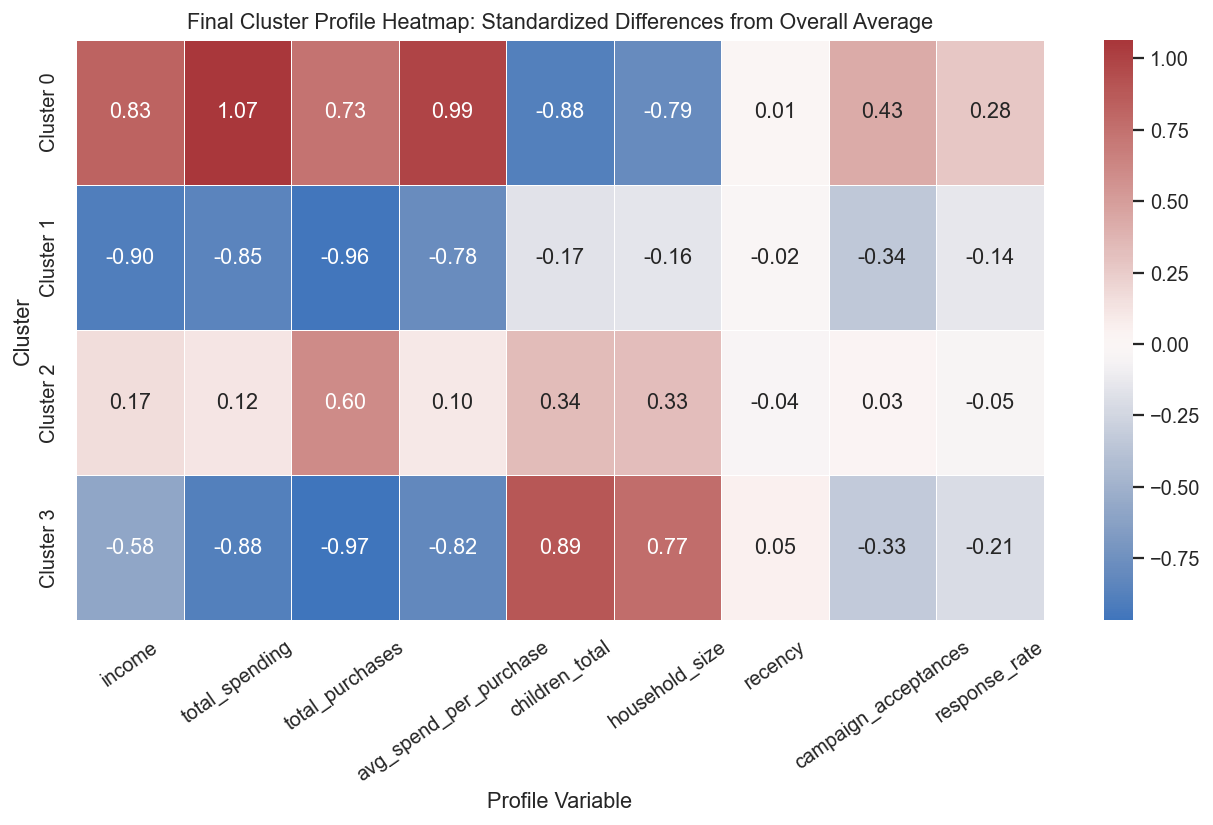

In [4]:
heatmap_vars = [
    "income",
    "total_spending",
    "total_purchases",
    "average_spend_per_purchase",
    "children_total",
    "household_size",
    "recency",
    "total_campaign_acceptances",
    "response",
]

cluster_means = customer_clustered.groupby("cluster")[heatmap_vars].mean()
global_means = customer_clustered[heatmap_vars].mean()
global_stds = customer_clustered[heatmap_vars].std().replace(0, np.nan)
standardized_profiles = ((cluster_means - global_means) / global_stds).fillna(0)
standardized_profiles = standardized_profiles.rename(columns={
    "response": "response_rate",
    "income": "income",
    "total_spending": "total_spending",
    "total_purchases": "total_purchases",
    "average_spend_per_purchase": "avg_spend_per_purchase",
    "children_total": "children_total",
    "household_size": "household_size",
    "recency": "recency",
    "total_campaign_acceptances": "campaign_acceptances",
})
standardized_profiles.index = [f"Cluster {idx}" for idx in standardized_profiles.index]

fig, ax = plt.subplots(figsize=(12, 5.8))
sns.heatmap(
    standardized_profiles,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Final Cluster Profile Heatmap: Standardized Differences from Overall Average")
ax.set_xlabel("Profile Variable")
ax.set_ylabel("Cluster")
ax.tick_params(axis="x", rotation=35)
save_figure(
    "final_cluster_profile_heatmap.png",
    "Final Cluster Profile Heatmap",
    "Cluster profiling",
    "Compare clusters across standardized business-relevant profile variables.",
    "Clusters differ meaningfully in income, spending, purchases, household structure, campaign acceptance, and response.",
)
plt.show()

## Final Visual B: Cluster Size Chart

This chart shows the number and percentage of customers in each cluster.

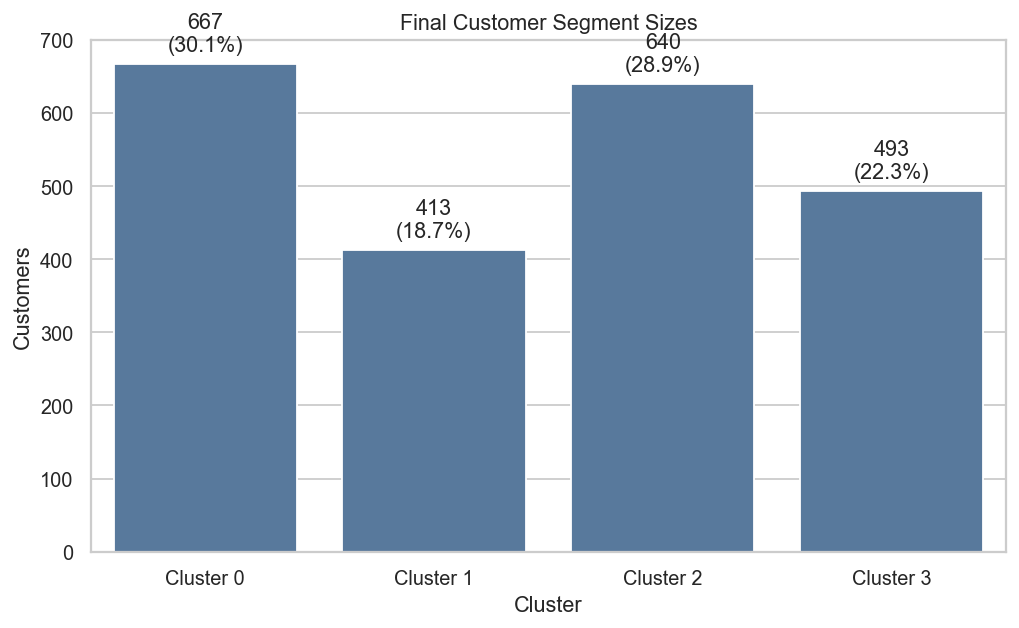

In [5]:
size_df = cluster_profile_summary.sort_values("cluster").copy()
size_df["cluster_short"] = size_df["cluster"].map(lambda value: f"Cluster {int(value)}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=size_df, x="cluster_short", y="cluster_size", color="#4C78A8", ax=ax)
ax.set_title("Final Customer Segment Sizes")
ax.set_xlabel("Cluster")
ax.set_ylabel("Customers")
for index, row in size_df.reset_index(drop=True).iterrows():
    ax.text(index, row["cluster_size"] + 12, f"{int(row['cluster_size'])}\n({row['cluster_pct']:.1f}%)", ha="center", va="bottom")
fig.tight_layout()
save_figure(
    "final_cluster_sizes.png",
    "Final Cluster Sizes",
    "Cluster profiling",
    "Show the size and percentage of each customer segment.",
    "The four retained clusters are reasonably sized, from about 19% to 30% of customers.",
)
plt.show()

## Final Visual C: Cluster Segment Comparison

This visual compares clusters on the most interpretable business variables from the profile summary.

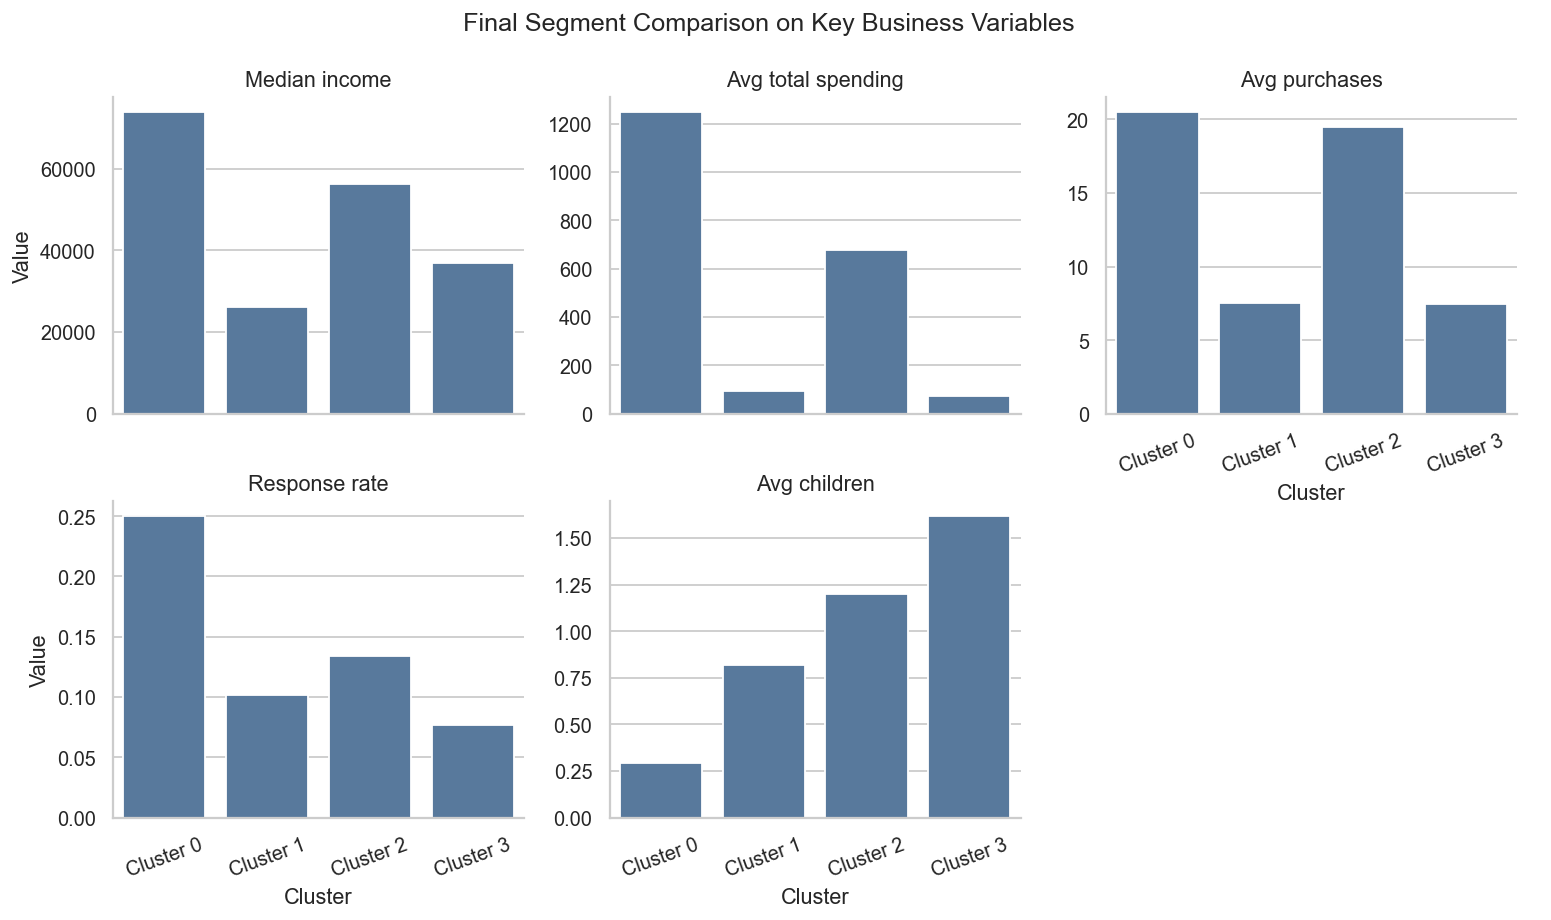

In [6]:
segment_metrics = cluster_profile_summary[
    [
        "cluster",
        "median_income",
        "avg_total_spending",
        "avg_total_purchases",
        "response_rate",
        "avg_children_total",
    ]
].copy()

long_segment_metrics = segment_metrics.melt(id_vars="cluster", var_name="metric", value_name="value")
metric_labels = {
    "median_income": "Median income",
    "avg_total_spending": "Avg total spending",
    "avg_total_purchases": "Avg purchases",
    "response_rate": "Response rate",
    "avg_children_total": "Avg children",
}
long_segment_metrics["metric_label"] = long_segment_metrics["metric"].map(metric_labels)
long_segment_metrics["cluster_label"] = long_segment_metrics["cluster"].map(lambda value: f"Cluster {int(value)}")

g = sns.catplot(
    data=long_segment_metrics,
    x="cluster_label",
    y="value",
    col="metric_label",
    kind="bar",
    color="#4C78A8",
    col_wrap=3,
    sharey=False,
    height=3.3,
    aspect=1.2,
)
g.set_axis_labels("Cluster", "Value")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=20)
g.fig.suptitle("Final Segment Comparison on Key Business Variables", y=1.04, fontsize=14)
save_figure(
    "final_cluster_segment_comparison.png",
    "Final Cluster Segment Comparison",
    "Cluster profiling",
    "Compare each cluster on interpretable business metrics.",
    "Cluster 0 stands out as high-income/high-spend; clusters 1 and 3 are lower-spend but differ in household structure; cluster 2 is family-heavy with strong purchasing.",
)
plt.show()

## Final Visual D: Response Rate by Cluster

This chart shows how the recent campaign response rate varied across the customer segments.

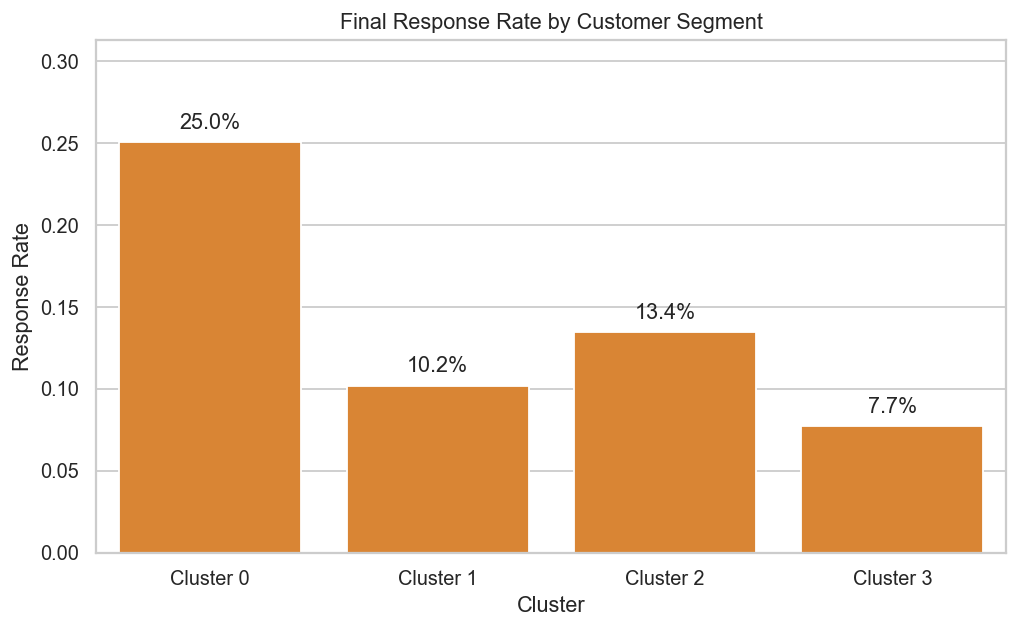

In [7]:
response_df = cluster_profile_summary.sort_values("cluster").copy()
response_df["cluster_short"] = response_df["cluster"].map(lambda value: f"Cluster {int(value)}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=response_df, x="cluster_short", y="response_rate", color="#F58518", ax=ax)
ax.set_title("Final Response Rate by Customer Segment")
ax.set_xlabel("Cluster")
ax.set_ylabel("Response Rate")
ax.set_ylim(0, max(response_df["response_rate"]) * 1.25)
for index, row in response_df.reset_index(drop=True).iterrows():
    ax.text(index, row["response_rate"] + 0.006, f"{row['response_rate']:.1%}", ha="center", va="bottom")
fig.tight_layout()
save_figure(
    "final_response_rate_by_cluster.png",
    "Final Response Rate by Cluster",
    "Cluster profiling",
    "Show whether segment membership aligns with different response rates.",
    "Cluster 0 had the highest response rate, while Cluster 3 had the lowest.",
)
plt.show()

## Final Visual E: Feature Set Comparison

This visual answers the modeling research question: clusters did not improve prediction from Feature Set A to B, while historical campaign behavior improved Feature Set C.

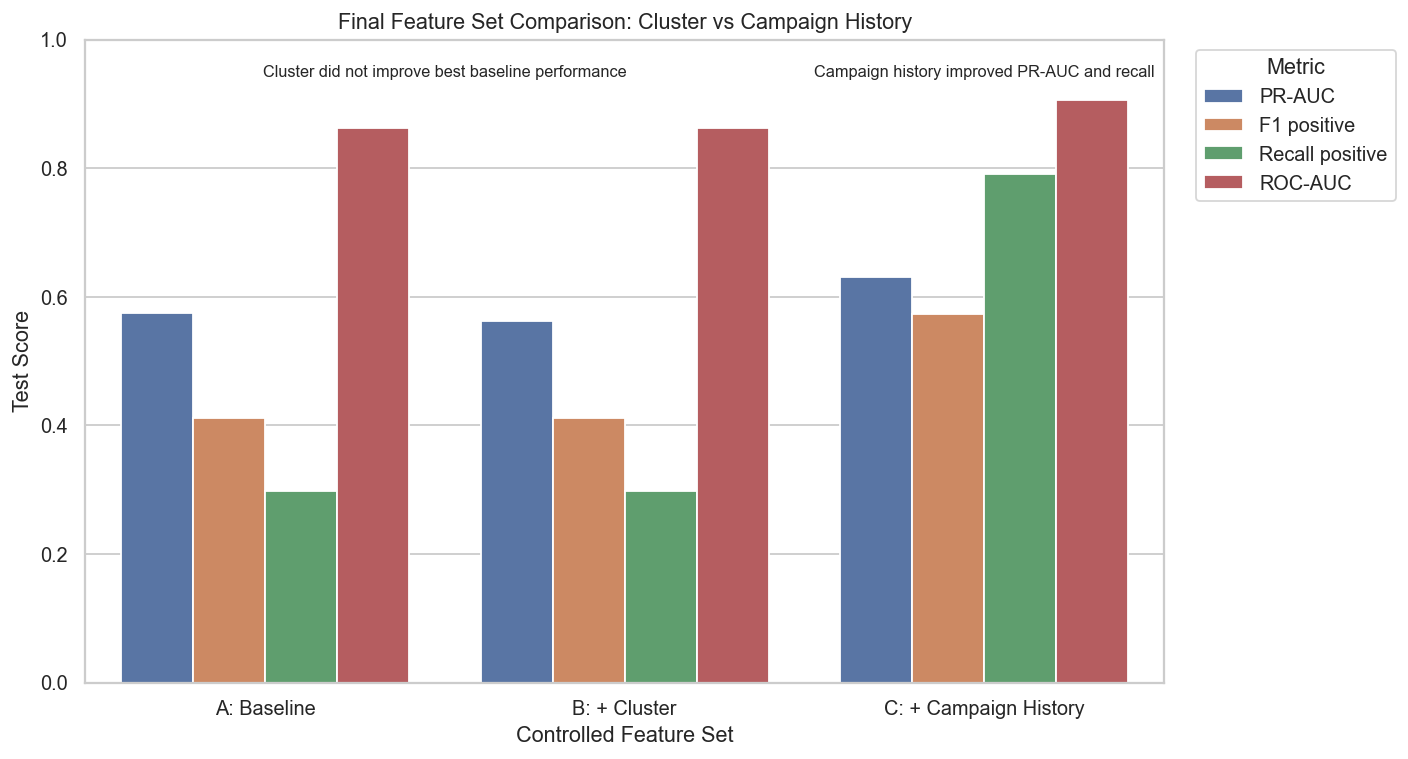

In [8]:
feature_set_order = [
    "A_baseline_customer_features",
    "B_baseline_plus_cluster",
    "C_full_with_campaign_history",
]
feature_set_labels = {
    "A_baseline_customer_features": "A: Baseline",
    "B_baseline_plus_cluster": "B: + Cluster",
    "C_full_with_campaign_history": "C: + Campaign History",
}
metric_order = ["pr_auc", "f1_positive", "recall_positive", "roc_auc"]
metric_display = {
    "pr_auc": "PR-AUC",
    "f1_positive": "F1 positive",
    "recall_positive": "Recall positive",
    "roc_auc": "ROC-AUC",
}

fs_plot = feature_set_comparison.copy()
fs_plot["feature_set_label"] = pd.Categorical(
    fs_plot["feature_set"].map(feature_set_labels),
    categories=[feature_set_labels[value] for value in feature_set_order],
    ordered=True,
)
fs_long = fs_plot.melt(
    id_vars=["feature_set", "feature_set_label"],
    value_vars=metric_order,
    var_name="metric",
    value_name="score",
)
fs_long["metric_label"] = fs_long["metric"].map(metric_display)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=fs_long, x="feature_set_label", y="score", hue="metric_label", ax=ax)
ax.set_title("Final Feature Set Comparison: Cluster vs Campaign History")
ax.set_xlabel("Controlled Feature Set")
ax.set_ylabel("Test Score")
ax.set_ylim(0, 1.0)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.text(0.5, 0.95, "Cluster did not improve best baseline performance", ha="center", va="center", fontsize=9)
ax.text(2.0, 0.95, "Campaign history improved PR-AUC and recall", ha="center", va="center", fontsize=9)
fig.tight_layout()
save_figure(
    "final_feature_set_comparison.png",
    "Final Feature Set Comparison",
    "Supervised modeling",
    "Compare best model performance for A, B, and C feature sets.",
    "Adding cluster did not improve prediction; adding historical campaign summaries improved performance.",
)
plt.show()

## Final Visual F: Model Comparison

This chart compares the strongest model-feature-set combinations using PR-AUC and positive-class F1.

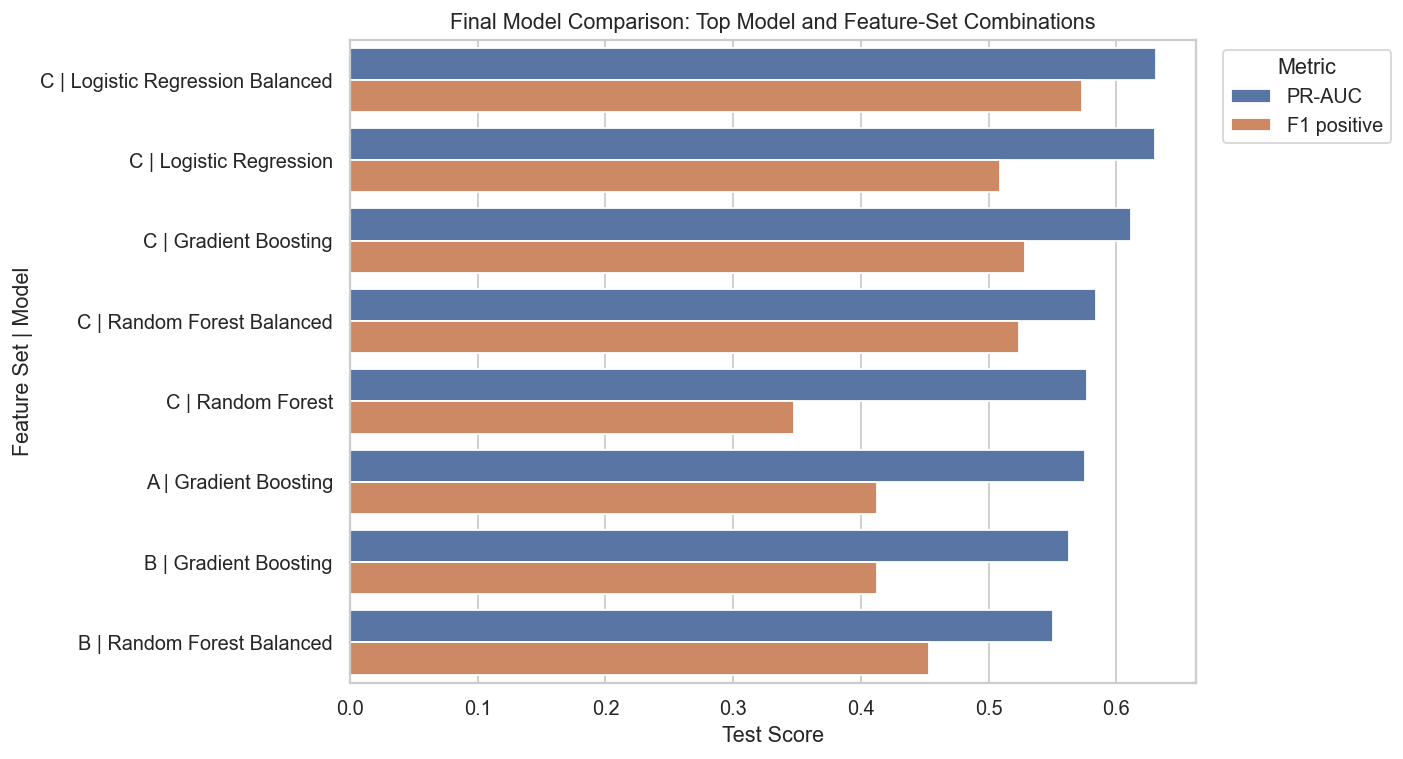

In [9]:
model_plot = model_evaluation_summary.copy()
model_plot["model_feature_label"] = (
    model_plot["feature_set"].str[0] + " | " + model_plot["model_name"]
)
top_models = model_plot.sort_values(["pr_auc", "f1_positive", "roc_auc"], ascending=False).head(8)
top_long = top_models.melt(
    id_vars=["feature_set", "model_name", "model_feature_label"],
    value_vars=["pr_auc", "f1_positive"],
    var_name="metric",
    value_name="score",
)
top_long["metric"] = top_long["metric"].map({"pr_auc": "PR-AUC", "f1_positive": "F1 positive"})

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_long, y="model_feature_label", x="score", hue="metric", ax=ax)
ax.set_title("Final Model Comparison: Top Model and Feature-Set Combinations")
ax.set_xlabel("Test Score")
ax.set_ylabel("Feature Set | Model")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_figure(
    "final_model_comparison.png",
    "Final Model Comparison",
    "Supervised modeling",
    "Compare strongest model-feature-set combinations by PR-AUC and F1.",
    "The best PR-AUC came from Feature Set C with balanced logistic regression.",
)
plt.show()

## Final Visual G: Threshold Tradeoff

Threshold results were not saved as a separate CSV in step 8, so this visual recreates the reported threshold table from the executed model training output. No model is retrained here.

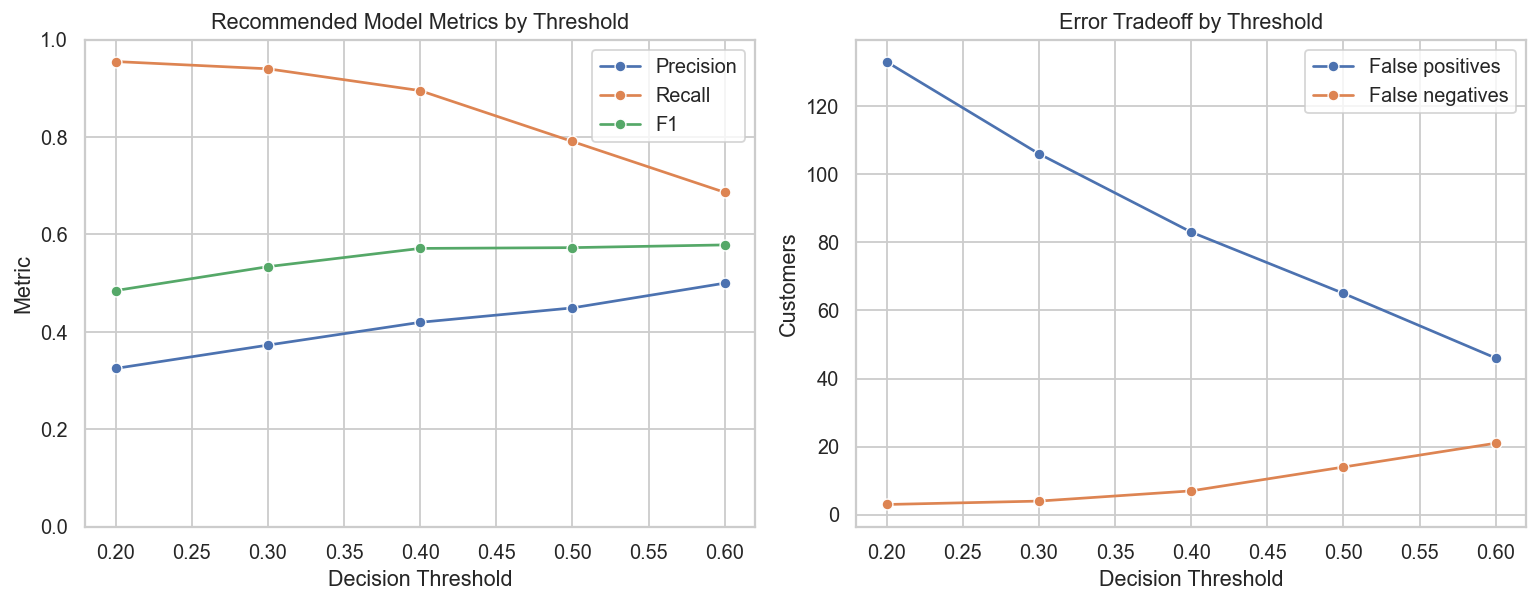

,threshold,precision_positive,recall_positive,f1_positive,false_positives,false_negatives
0,0.2,0.3249,0.9552,0.4848,133,3
1,0.3,0.3728,0.9403,0.5339,106,4
2,0.4,0.4196,0.8955,0.5714,83,7
3,0.5,0.4492,0.7910,0.5730,65,14
4,0.6,0.5000,0.6866,0.5786,46,21


In [10]:
threshold_df = pd.DataFrame(
    {
        "threshold": [0.20, 0.30, 0.40, 0.50, 0.60],
        "precision_positive": [0.3249, 0.3728, 0.4196, 0.4492, 0.5000],
        "recall_positive": [0.9552, 0.9403, 0.8955, 0.7910, 0.6866],
        "f1_positive": [0.4848, 0.5339, 0.5714, 0.5730, 0.5786],
        "false_positives": [133, 106, 83, 65, 46],
        "false_negatives": [3, 4, 7, 14, 21],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.lineplot(data=threshold_df, x="threshold", y="precision_positive", marker="o", label="Precision", ax=axes[0])
sns.lineplot(data=threshold_df, x="threshold", y="recall_positive", marker="o", label="Recall", ax=axes[0])
sns.lineplot(data=threshold_df, x="threshold", y="f1_positive", marker="o", label="F1", ax=axes[0])
axes[0].set_title("Recommended Model Metrics by Threshold")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("Metric")
axes[0].set_ylim(0, 1.0)

sns.lineplot(data=threshold_df, x="threshold", y="false_positives", marker="o", label="False positives", ax=axes[1])
sns.lineplot(data=threshold_df, x="threshold", y="false_negatives", marker="o", label="False negatives", ax=axes[1])
axes[1].set_title("Error Tradeoff by Threshold")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Customers")

fig.tight_layout()
save_figure(
    "final_threshold_tradeoff.png",
    "Final Threshold Tradeoff",
    "Supervised modeling",
    "Show precision, recall, F1, false positives, and false negatives across thresholds.",
    "Lower thresholds catch more responders but create more false positives; higher thresholds are more precise but miss more responders.",
)
plt.show()
display(threshold_df)

## Final Visual H: Project Workflow

This simple workflow visual summarizes the full project sequence from raw data through final findings.

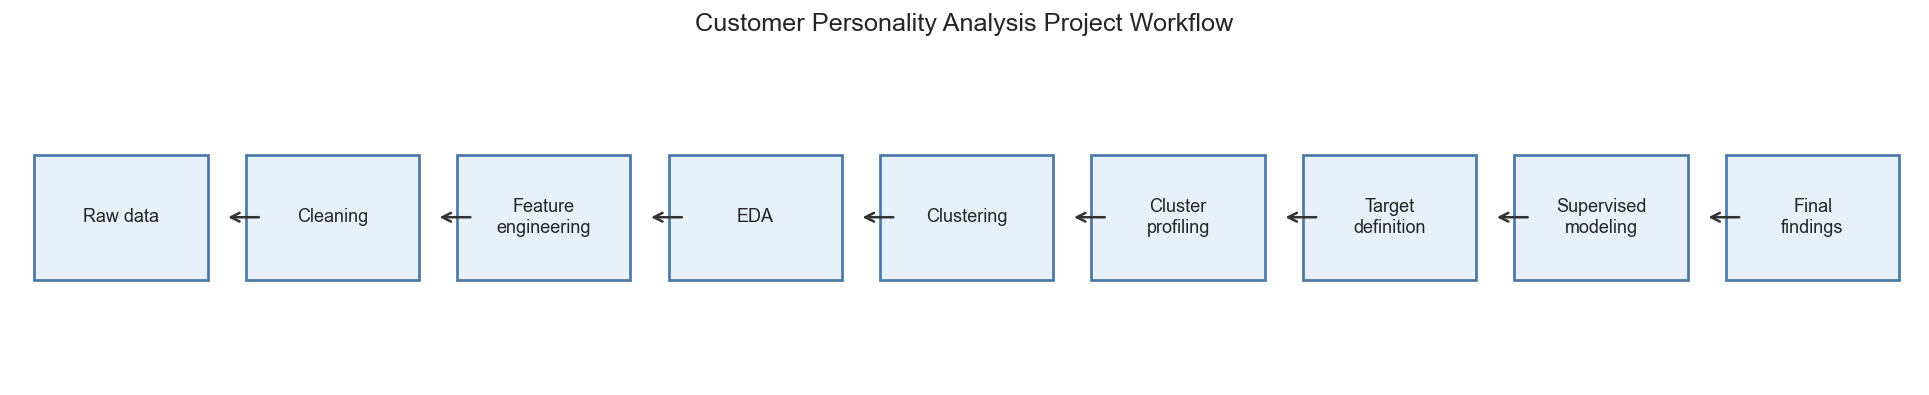

In [11]:
workflow_steps = [
    "Raw data",
    "Cleaning",
    "Feature\nengineering",
    "EDA",
    "Clustering",
    "Cluster\nprofiling",
    "Target\ndefinition",
    "Supervised\nmodeling",
    "Final\nfindings",
]

fig, ax = plt.subplots(figsize=(15, 3.2))
ax.set_xlim(0, len(workflow_steps))
ax.set_ylim(0, 1)
ax.axis("off")

box_width = 0.82
box_height = 0.38
y = 0.5

for idx, step in enumerate(workflow_steps):
    x = idx + 0.1
    box = plt.Rectangle((x, y - box_height / 2), box_width, box_height, facecolor="#E8F1FA", edgecolor="#4C78A8", linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + box_width / 2, y, step, ha="center", va="center", fontsize=10)
    if idx < len(workflow_steps) - 1:
        ax.annotate(
            "",
            xy=(x + box_width + 0.08, y),
            xytext=(x + box_width + 0.26, y),
            arrowprops=dict(arrowstyle="->", color="#333333", lw=1.4),
        )

ax.set_title("Customer Personality Analysis Project Workflow", fontsize=14, pad=12)
fig.tight_layout()
save_figure(
    "final_project_workflow.png",
    "Final Project Workflow",
    "Project summary",
    "Summarize the project workflow from raw data to final findings.",
    "The project combines segmentation and supervised prediction in a structured data science workflow.",
)
plt.show()

## Save Final Visuals Summary

The summary CSV documents every final figure, its project section, purpose, and key message.

In [12]:
final_visuals_summary = pd.DataFrame(figure_records)
expected_final_figures = [
    "final_cluster_profile_heatmap.png",
    "final_cluster_sizes.png",
    "final_cluster_segment_comparison.png",
    "final_response_rate_by_cluster.png",
    "final_feature_set_comparison.png",
    "final_model_comparison.png",
    "final_threshold_tradeoff.png",
    "final_project_workflow.png",
]

missing_final_figures = [
    filename for filename in expected_final_figures if not (FIGURE_DIR / filename).exists()
]
if missing_final_figures:
    raise FileNotFoundError(f"Missing final figures: {missing_final_figures}")

final_visuals_summary.to_csv(SUMMARY_PATH, index=False)
display(final_visuals_summary)
print(f"Saved final visuals summary to: {SUMMARY_PATH}")

,figure_filename,figure_title,project_section,purpose,key_message
0,final_cluster_profile_heatmap.png,Final Cluster Profile Heatmap,Cluster profiling,Compare clusters across standardized business-...,"Clusters differ meaningfully in income, spendi..."
1,final_cluster_sizes.png,Final Cluster Sizes,Cluster profiling,Show the size and percentage of each customer ...,The four retained clusters are reasonably size...
2,final_cluster_segment_comparison.png,Final Cluster Segment Comparison,Cluster profiling,Compare each cluster on interpretable business...,Cluster 0 stands out as high-income/high-spend...
3,final_response_rate_by_cluster.png,Final Response Rate by Cluster,Cluster profiling,Show whether segment membership aligns with di...,"Cluster 0 had the highest response rate, while..."
4,final_feature_set_comparison.png,Final Feature Set Comparison,Supervised modeling,"Compare best model performance for A, B, and C...",Adding cluster did not improve prediction; add...
5,final_model_comparison.png,Final Model Comparison,Supervised modeling,Compare strongest model-feature-set combinatio...,The best PR-AUC came from Feature Set C with b...
6,final_threshold_tradeoff.png,Final Threshold Tradeoff,Supervised modeling,"Show precision, recall, F1, false positives, a...",Lower thresholds catch more responders but cre...
7,final_project_workflow.png,Final Project Workflow,Project summary,Summarize the project workflow from raw data t...,The project combines segmentation and supervis...


Saved final visuals summary to: /Users/arjun/Documents/Intro DS final/reports/final_visuals_summary.csv


## Final Visuals Interpretation Summary

**Most important visuals for the final report**

- `final_cluster_profile_heatmap.png`: best single visual for explaining how clusters differ.
- `final_cluster_segment_comparison.png`: easiest visual for communicating segment business differences.
- `final_feature_set_comparison.png`: best visual for answering whether clusters improved prediction.
- `final_threshold_tradeoff.png`: best visual for explaining why threshold choice matters with an imbalanced target.
- `final_project_workflow.png`: useful overview slide/figure for the final writeup.

**Main conclusion about clusters**

The clusters are interpretable and useful for segmentation: they differ in income, spending, purchase behavior, household structure, campaign acceptance, and response rate. However, the cluster label did not improve supervised response prediction beyond the customer features used to create it.

**Main conclusion about supervised prediction**

Historical campaign behavior improved supervised model performance. Because the response target is imbalanced, PR-AUC, recall, F1, and threshold tradeoffs are more informative than accuracy alone.

**Limitations of the visuals**

The visuals summarize associations, not causal effects. Threshold results are recreated from the reported step 8 output rather than a separate saved threshold CSV. The model comparison is based on the earlier fixed train/test split and should not be overgeneralized as a production estimate.

In [13]:
print("Final figures created:")
for path in sorted(FIGURE_DIR.glob("final_*.png")):
    print(f"- {path}")

print(f"Final visuals summary rows: {len(final_visuals_summary)}")
assert len(final_visuals_summary) == len(expected_final_figures)

Final figures created:
- /Users/arjun/Documents/Intro DS final/reports/figures/final_cluster_profile_heatmap.png
- /Users/arjun/Documents/Intro DS final/reports/figures/final_cluster_segment_comparison.png
- /Users/arjun/Documents/Intro DS final/reports/figures/final_cluster_sizes.png
- /Users/arjun/Documents/Intro DS final/reports/figures/final_feature_set_comparison.png
- /Users/arjun/Documents/Intro DS final/reports/figures/final_model_comparison.png
- /Users/arjun/Documents/Intro DS final/reports/figures/final_project_workflow.png
- /Users/arjun/Documents/Intro DS final/reports/figures/final_response_rate_by_cluster.png
- /Users/arjun/Documents/Intro DS final/reports/figures/final_threshold_tradeoff.png
Final visuals summary rows: 8
